# Распознавание рукописных цифр нейронной сетью с плотными слоями












Практическая работа №3

по дисциплине

Нейросетевые системы



Выполнил: студент группы АТ-24д

Рогалев Глеб Иванович

Проверил:

Михайлов И. С.




In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


# Распознавание рукописных цифр сверточной нейронной сетью

In [2]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# В Keras встроены средства работы с популярными наборами данных
(x_train_org, y_train_org), (x_test_org, y_test_org) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print(x_train_org.shape)
print(y_train_org.shape)
print(x_test_org.shape)
print(y_test_org.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [5]:
x_train = x_train_org.astype('float32')
x_train = x_train / 255

x_test = x_test_org.astype('float32')
x_test = x_test / 255

In [6]:
x_train = np.expand_dims(x_train, axis=3)
x_test = np.expand_dims(x_test, axis=3)

In [7]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [8]:
y_train = utils.to_categorical(y_train_org, 10)
y_test = utils.to_categorical(y_test_org, 10)

In [9]:
model = Sequential()
#model.add(BatchNormalization(input_shape=(28, 28, 1)))

model.add(Conv2D(32, kernel_size=(4, 4), padding='same', input_shape=(28, 28, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(BatchNormalization())
model.add(Conv2D(64, kernel_size=(4, 4), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(BatchNormalization())
model.add(Conv2D(128, kernel_size=(4, 4), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 432,746 (1.65 MB)

 Trainable params: 432,554 (1.65 MB)

 Non-trainable params: 192 (768.00 B)

None


In [11]:
model.fit(x_train, y_train, batch_size=200, epochs=7,  verbose=1)

Epoch 1/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9127 - loss: 0.2731
Epoch 2/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9767 - loss: 0.0744
Epoch 3/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9834 - loss: 0.0533
Epoch 4/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9861 - loss: 0.0446
Epoch 5/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9877 - loss: 0.0392
Epoch 6/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9895 - loss: 0.0343
Epoch 7/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9905 - loss: 0.0318


In [12]:
# Оцениваем качество обучения сети на тестовых данных
scores = model.evaluate(x_test, y_test, verbose=0)
print("Точность работы на тестовых данных: %.2f%%" % (scores[1]*100))

Точность работы на тестовых данных: 99.22%


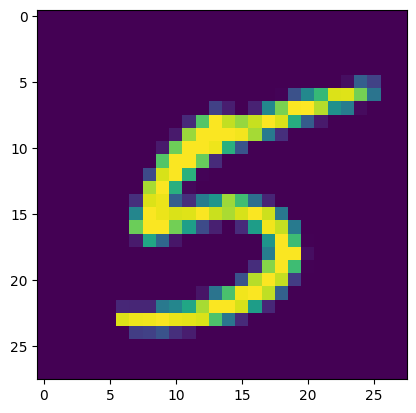

5
(28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 627ms/step
[[7.3202358e-15 1.9059344e-14 8.7762566e-16 4.9828149e-08 3.2222677e-16
  1.0000000e+00 1.5740615e-11 1.3460123e-14 3.6074567e-11 2.1109088e-10]]


In [13]:
n=52
#Вывод тестируемой цифры
img = x_test_org[n,:,:]
plt.imshow(img)
plt.show()
print(y_test_org[n])
#Подготовка данных для подачи на сеть
X = x_test[n,:,:,:]
print(X.shape)
X = np.expand_dims(X, axis=0)
prediction = model.predict(X)
print(prediction)

In [14]:
prediction = np.argmax(prediction)
print(prediction)

5


In [15]:
print("Сохраняем сеть")
# Сохраняем сеть для последующего использования
# Генерируем описание модели в формате json
model_json = model.to_json()
json_file = open("mnist_model_CNN.json", "w")
# Записываем архитектуру сети в файл
json_file.write(model_json)
json_file.close()
# Записываем данные о весах в файл
model.save_weights("mnist_model_CNN.weights.h5")
print("Сохранение сети завершено")

Сохраняем сеть
Сохранение сети завершено


In [16]:
from tensorflow.keras.models import model_from_json

print("Загружаю сеть из файлов")
# Загружаем данные об архитектуре сети
json_file = open("mnist_model_CNN.json", "r")
loaded_model_json = json_file.read()
json_file.close()
# Создаем модель
loaded_model = model_from_json(loaded_model_json)
# Загружаем сохраненные веса в модель
loaded_model.load_weights("mnist_model_CNN.weights.h5")
print("Загрузка сети завершена")

Загружаю сеть из файлов
Загрузка сети завершена


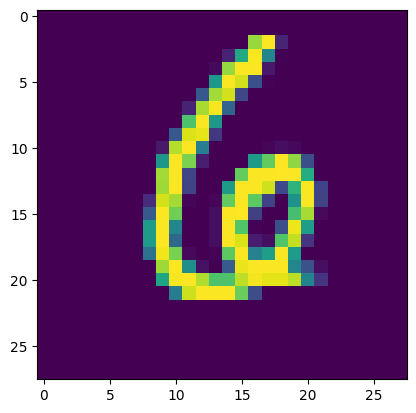

6
(28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step
[[7.80167597e-11 1.07920265e-13 9.80102501e-13 1.89168309e-14
  2.21515948e-11 1.27291649e-10 1.00000000e+00 2.87278530e-16
  2.67004144e-11 1.55389839e-12]]


In [17]:
n=123
#Вывод тестируемой цифры
img = x_test_org[n,:,:]
plt.imshow(img)
plt.show()
print(y_test_org[n])
#Подготовка данных для подачи на сеть
X = x_test[n,:,:,:]
print(X.shape)
X = np.expand_dims(X, axis=0)
prediction = loaded_model.predict(X)
print(prediction)

In [18]:
prediction = np.argmax(prediction)
print(prediction)

6


# Тестирование собственного изображения

(28, 28, 3)


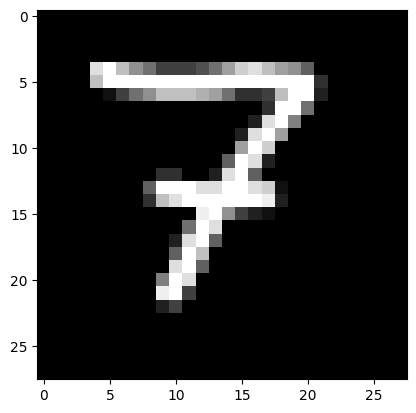

(28, 28)


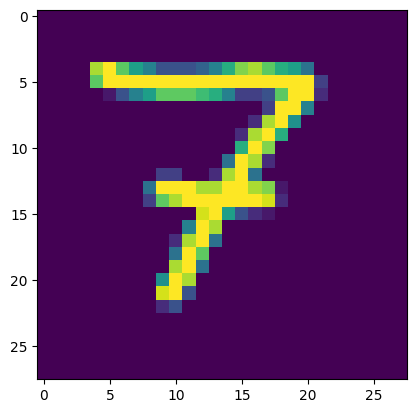

In [19]:
import cv2

#Загружаем изображение
image = cv2.imread('/content/gdrive/MyDrive/seven.png')
print(image.shape)
plt.imshow(image)
plt.show()
#Загружаем изображение в оттенках серого
image = cv2.imread('/content/gdrive/MyDrive/seven.png', cv2.IMREAD_GRAYSCALE)
print(image.shape)
#Отображение файла встроенными средствами OpenCV.
plt.imshow(image)
plt.show()

In [20]:
dim=(28,28)
resized = cv2.resize(image, dim, interpolation = cv2.INTER_AREA)
print(resized.shape)

(28, 28)


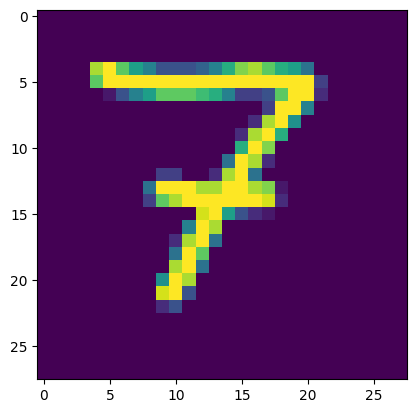

In [21]:
plt.imshow(resized.reshape(28,28))

In [22]:
resized  = resized.astype('float32')
resized = resized / 255

In [23]:
resized = np.expand_dims(resized, axis=0)
resized = np.expand_dims(resized, axis=3)
print(resized.shape)

(1, 28, 28, 1)


In [24]:
prediction = loaded_model.predict(resized)
print(prediction)
prediction = np.argmax(prediction)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[1.5034166e-10 5.7339294e-05 2.2689563e-05 9.7418570e-06 3.7857113e-04
  5.8174720e-08 5.9287319e-10 9.9951172e-01 3.8093817e-06 1.6138747e-05]]
7
